In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd

from src.utils import (
    FileManager,
    DataInspector
)

from src.visualization import (
    ModelVisualizer,
    BusinessVisualizer
)

from src.reporting import (
    BusinessReportGenerator
)


In [3]:
# Load the data

df = pd.read_csv(r"D:\GIT\data-analytics-portfolio\02-telco-customer-churn\data\processed\telco_customer_churn_model_data.csv")

df.head()

,seniorcitizen,tenure,monthlycharges,totalcharges,charge_per_month_tenure,num_additional_services,gender_Male,partner_Yes,dependents_Yes,phoneservice_Yes,...,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,churn,tenure_group_developing,tenure_group_established,tenure_group_loyal,charge_band_medium,charge_band_high,charge_band_premium
0,0,1,29.85,29.85,14.925000,1,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
1,0,34,56.95,1889.50,53.985714,2,True,False,False,True,...,False,False,True,False,False,True,False,True,False,False
2,0,2,53.85,108.15,36.050000,2,True,False,False,True,...,False,False,True,True,False,False,False,True,False,False
3,0,45,42.30,1840.75,40.016304,3,True,False,False,False,...,False,False,False,False,False,True,False,True,False,False
4,0,2,70.70,151.65,50.550000,0,False,False,False,True,...,False,True,False,True,False,False,False,False,True,False


### Data Inspection

In [4]:
DataInspector.dataset_summary(df)


rows              7021.000
columns             39.000
duplicate_rows       0.000
missing_values       0.000
memory_mb            0.542
Name: dataset_summary, dtype: float64

In [5]:
DataInspector.missing_values(df)

,missing_count,missing_percentage


In [6]:
comparison_df = pd.read_csv(
    "../reports/model_performance.csv"
)

comparison_df


,Unnamed: 0,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.807829,0.678322,0.521505,0.589666,0.716222
1,Gradient Boosting,0.799288,0.657343,0.505376,0.571429,0.705254
2,XGBoost,0.784342,0.616162,0.491935,0.547085,0.690789
3,Random Forest,0.791459,0.644689,0.473118,0.545736,0.689609


In [7]:
comparison_df.sort_values(
    by=["Recall", "F1 Score"],
    ascending=False
)


,Unnamed: 0,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.807829,0.678322,0.521505,0.589666,0.716222
1,Gradient Boosting,0.799288,0.657343,0.505376,0.571429,0.705254
2,XGBoost,0.784342,0.616162,0.491935,0.547085,0.690789
3,Random Forest,0.791459,0.644689,0.473118,0.545736,0.689609


### Identifying Best Model

In [8]:
best_model = (
    BusinessReportGenerator
    .create_model_summary(
        comparison_df
    )
)

best_model


Unnamed: 0    Logistic Regression
Accuracy                 0.807829
Precision                0.678322
Recall                   0.521505
F1 Score                 0.589666
ROC-AUC                  0.716222
Name: 0, dtype: object

The Logistic Regression model has the highest ability to identify customers
who are likely to churn.

Since customer churn detection prioritizes Recall, this model
minimizes false negatives and helps reduce customer loss.


### Feature Importance

In [9]:
from src.modeling import (
    prepare_train_test,
    scale_features,
    LogisticRegressionTrainer,
    RandomForestTrainer,
    GradientBoostingTrainer,
    XGBoostTrainer,
    ModelComparer,
    save_model,
    load_model
)


In [10]:
log_model = load_model(r"D:\GIT\data-analytics-portfolio\02-telco-customer-churn\models\logistic_regression.pkl")   

In [11]:
feature_importance_df = (
BusinessReportGenerator
.create_logistic_feature_importance(
log_model,
df.drop(columns=["churn"]).columns
)
)

feature_importance_df.head(10)

,Feature,Coefficient,Abs_Coefficient
1,tenure,-1.041544,1.041544
4,charge_per_month_tenure,-1.004152,1.004152
27,contract_Two year,-0.696404,0.696404
12,internetservice_Fiber optic,0.677339,0.677339
3,totalcharges,0.470659,0.470659
26,contract_One year,-0.299693,0.299693
11,multiplelines_Yes,0.237051,0.237051
25,streamingmovies_Yes,0.220066,0.220066
23,streamingtv_Yes,0.197613,0.197613
28,paperlessbilling_Yes,0.165847,0.165847


In [12]:
print(type(log_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


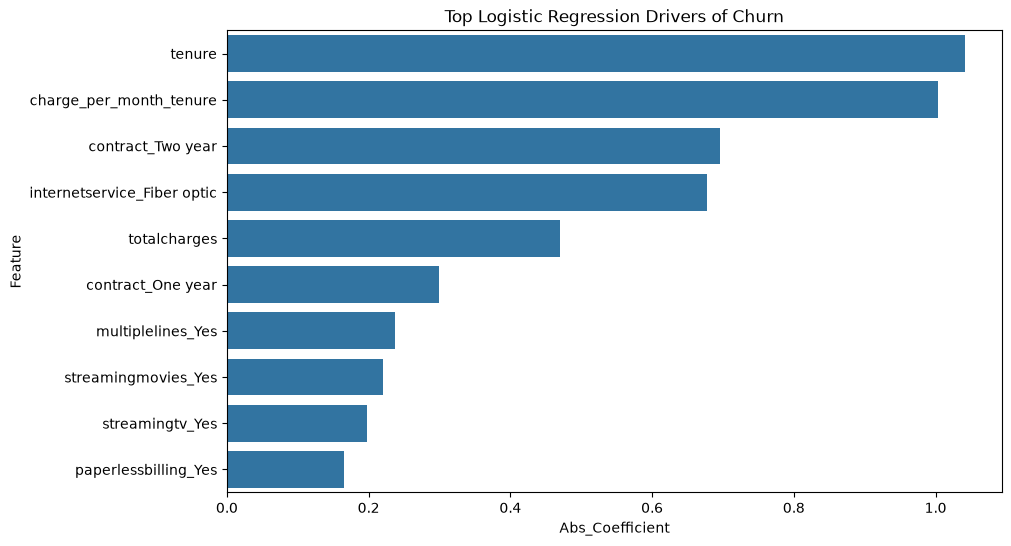

In [13]:
top_features = (
    feature_importance_df
    .head(10)
)

ModelVisualizer.plot_feature_importance(
    top_features,
    top_n=10
)

# Top Drivers of Customer Churn

The Logistic Regression model identified several variables that have the strongest influence on whether a customer is likely to leave the company. The magnitude of each coefficient indicates the relative importance of that feature in the churn prediction process.

## Key Findings

### 1. Customer Tenure
Customer tenure emerged as the most influential predictor of churn. Customers with shorter service durations are significantly more likely to leave, suggesting that the early stages of the customer lifecycle represent the highest-risk period.

### 2. Monthly Charge Relative to Tenure
The feature `charge_per_month_tenure` was the second strongest predictor. This indicates that customers paying higher monthly charges relative to the length of their relationship with the company are more likely to churn. Perceived value for money may therefore be an important retention factor.

### 3. Contract Type
Contract-related variables were among the strongest drivers of churn:

- Two-year contracts showed a substantial influence on churn behaviour.
- One-year contracts also played an important role.

This suggests that contract commitment is closely associated with customer retention, with longer-term contractual agreements generally linked to lower churn risk.

### 4. Fibre Optic Internet Service
Customers subscribed to fibre optic internet services were identified as a key customer segment influencing churn predictions. This may indicate differences in customer expectations, pricing sensitivity, or service experience within this group.

### 5. Total Charges
Total amount spent over the customer lifetime was also an important predictor. This reinforces the relationship between customer value, tenure, and retention behaviour.

### 6. Additional Services and Billing Preferences
Several service-related features contributed to churn prediction, including:

- Multiple lines
- Streaming TV
- Streaming movies
- Paperless billing

Although these factors were less influential than tenure and contract-related variables, they still provide useful signals for identifying customers at risk of leaving.

## Business Implications

Based on the model results, retention efforts should focus primarily on:

1. New and recently acquired customers.
2. Customers on month-to-month agreements.
3. Fibre optic internet subscribers.
4. Customers with high monthly costs relative to their tenure.
5. Customers showing characteristics associated with lower long-term commitment.

Targeted onboarding programmes, contract renewal incentives, and proactive engagement campaigns for high-risk customer segments could significantly reduce customer churn and improve customer lifetime value.

### Risk And Protective Factors

In [14]:
# Features increasing churn risk
risk_factors = (
    feature_importance_df
    .sort_values(
        by="Coefficient",
        ascending=False
    )
    .head(10)
)

risk_factors


,Feature,Coefficient,Abs_Coefficient
12,internetservice_Fiber optic,0.677339,0.677339
3,totalcharges,0.470659,0.470659
11,multiplelines_Yes,0.237051,0.237051
25,streamingmovies_Yes,0.220066,0.220066
23,streamingtv_Yes,0.197613,0.197613
28,paperlessbilling_Yes,0.165847,0.165847
2,monthlycharges,0.157263,0.157263
30,paymentmethod_Electronic check,0.128259,0.128259
0,seniorcitizen,0.093226,0.093226
34,tenure_group_loyal,0.078294,0.078294


In [15]:
# Features reducing churn risk
protective_factors = (
    feature_importance_df
    .sort_values(
        by="Coefficient",
        ascending=True
    )
    .head(10)
)

protective_factors


,Feature,Coefficient,Abs_Coefficient
1,tenure,-1.041544,1.041544
4,charge_per_month_tenure,-1.004152,1.004152
27,contract_Two year,-0.696404,0.696404
26,contract_One year,-0.299693,0.299693
15,onlinesecurity_Yes,-0.107193,0.107193
8,dependents_Yes,-0.084933,0.084933
21,techsupport_Yes,-0.084225,0.084225
24,streamingmovies_No internet service,-0.073215,0.073215
14,onlinesecurity_No internet service,-0.073215,0.073215
22,streamingtv_No internet service,-0.073215,0.073215


### Odds Ratio Analysis

In [16]:
import numpy as np

feature_importance_df["Odds_Ratio"] = np.exp(
    feature_importance_df["Coefficient"]
)

feature_importance_df.head()


,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
1,tenure,-1.041544,1.041544,0.352909
4,charge_per_month_tenure,-1.004152,1.004152,0.366355
27,contract_Two year,-0.696404,0.696404,0.498374
12,internetservice_Fiber optic,0.677339,0.677339,1.968633
3,totalcharges,0.470659,0.470659,1.601049


# Odds Ratio Analysis Interpretation

The Logistic Regression model provides insights into how each feature affects the likelihood of customer churn.

## Key Findings

### 1. Customer Tenure
- **Coefficient:** -1.042
- **Odds Ratio:** 0.353

Interpretation:

Customers with longer tenure are significantly less likely to churn.

An odds ratio of **0.353** means that for a one-unit increase in tenure (after scaling/engineering), the odds of churn are multiplied by **0.353**, representing approximately a **64.7% reduction** in churn odds.

**Business Insight:** Retaining customers beyond the early stages of their relationship is critical. Loyalty and retention programs should focus on new customers.



### 2. Charge per Month per Tenure
- **Coefficient:** -1.004
- **Odds Ratio:** 0.366

Interpretation:

Higher values of the charge-per-month-tenure metric are associated with lower churn risk.

An odds ratio of **0.366** indicates approximately a **63.4% reduction** in churn odds.

**Business Insight:** Customers generating higher value over time tend to be more loyal and should be prioritized for retention and upselling initiatives.



### 3. Two-Year Contract
- **Coefficient:** -0.696
- **Odds Ratio:** 0.498

Interpretation:

Customers on a two-year contract are much less likely to churn than customers in the reference contract category.

An odds ratio of **0.498** implies approximately a **50.2% reduction** in churn odds.

**Business Insight:** Long-term contracts are one of the strongest protective factors against churn. The company should actively promote annual and multi-year contracts.



### 4. Fibre Optic Internet Service
- **Coefficient:** 0.677
- **Odds Ratio:** 1.969

Interpretation:

Customers using fibre optic internet are more likely to churn than customers in the reference internet service category.

An odds ratio of **1.969** means these customers are approximately **1.97 times more likely** to churn.

**Business Insight:** Fibre optic customers represent a high-risk segment and may require targeted retention offers, service improvements, or pricing reviews.



### 5. Total Charges
- **Coefficient:** 0.471
- **Odds Ratio:** 1.601

Interpretation:

Higher total charges are associated with increased churn likelihood.

An odds ratio of **1.601** indicates that churn odds increase by approximately **60.1%**.

**Business Insight:** Customers paying higher overall charges may perceive lower value for money and should be monitored closely for retention opportunities.



# Business Conclusion

The strongest factors **reducing churn** are:

1. Longer customer tenure
2. Higher charge-per-month-tenure value
3. Two-year contracts

The strongest factors **increasing churn** are:

1. Fibre optic internet service
2. Higher total charges

## Recommended Actions

- Encourage customers to switch to long-term contracts.
- Strengthen onboarding and engagement for new customers.
- Review pricing and service quality for fibre optic customers.
- Monitor high-bill customers and provide personalized retention incentives.
- Develop targeted campaigns for customers identified as high risk by the Logistic Regression model.

Overall, the analysis suggests that **customer loyalty (tenure and contract commitment) is the strongest protection against churn**, while **service type and cost-related factors are the main drivers of customer attrition.**

### Customer Risk Profiles

In [18]:
print(df.columns)

Index(['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges',
       'charge_per_month_tenure', 'num_additional_services', 'gender_Male',
       'partner_Yes', 'dependents_Yes', 'phoneservice_Yes',
       'multiplelines_No phone service', 'multiplelines_Yes',
       'internetservice_Fiber optic', 'internetservice_No',
       'onlinesecurity_No internet service', 'onlinesecurity_Yes',
       'onlinebackup_No internet service', 'onlinebackup_Yes',
       'deviceprotection_No internet service', 'deviceprotection_Yes',
       'techsupport_No internet service', 'techsupport_Yes',
       'streamingtv_No internet service', 'streamingtv_Yes',
       'streamingmovies_No internet service', 'streamingmovies_Yes',
       'contract_One year', 'contract_Two year', 'paperlessbilling_Yes',
       'paymentmethod_Credit card (automatic)',
       'paymentmethod_Electronic check', 'paymentmethod_Mailed check', 'churn',
       'tenure_group_developing', 'tenure_group_established',
       'tenure_grou

In [19]:
df["contract"] = "Month-to-month"

df.loc[
    df["contract_One year"] == 1,
    "contract"
] = "One year"

df.loc[
    df["contract_Two year"] == 1,
    "contract"
] = "Two year"

In [20]:
df["contract"].value_counts()

contract
Month-to-month    3853
Two year          1695
One year          1473
Name: count, dtype: int64

In [21]:
contract_risk = (
    BusinessReportGenerator
    .create_risk_profile(
        df,
        group_column="contract",
        target_column="churn"
    )
)

contract_risk

,contract,churn
0,Month-to-month,0.426421
1,One year,0.112695
2,Two year,0.028319


In [23]:
import numpy as np

df["tenure_group"] = np.select(
    [
        df["tenure_group_loyal"] == 1,
        df["tenure_group_established"] == 1,
        df["tenure_group_developing"] == 1
    ],
    [
        "Loyal",
        "Established",
        "Developing"
    ],
    default="New"
)

In [24]:
# Analyze churn risk by tenure

tenure_risk = (
    BusinessReportGenerator
    .create_risk_profile(
        df,
        group_column="tenure_group",
        target_column="churn"
    )
)

tenure_risk


,tenure_group,churn
0,New,0.473660
1,Developing,0.287109
2,Established,0.203890
3,Loyal,0.095132


In [25]:
# reconstructing the missing charge_band

#import numpy as np

# Recreate charge_band from encoded features
df["charge_band"] = np.select(
    [
        df["charge_band_premium"] == 1,
        df["charge_band_high"] == 1,
        df["charge_band_medium"] == 1
    ],
    [
        "Premium",
        "High",
        "Medium"
    ],
    default="Low"
)

# Verify
df["charge_band"].value_counts()

charge_band
Medium     1758
Premium    1758
High       1757
Low        1748
Name: count, dtype: int64

In [26]:
charge_risk = (
    BusinessReportGenerator
    .create_risk_profile(
        df,
        group_column="charge_band",
        target_column="churn"
    )
)

charge_risk


,charge_band,churn
0,High,0.375071
1,Premium,0.328783
2,Medium,0.242321
3,Low,0.110984


### Visualizing High Risk Segments

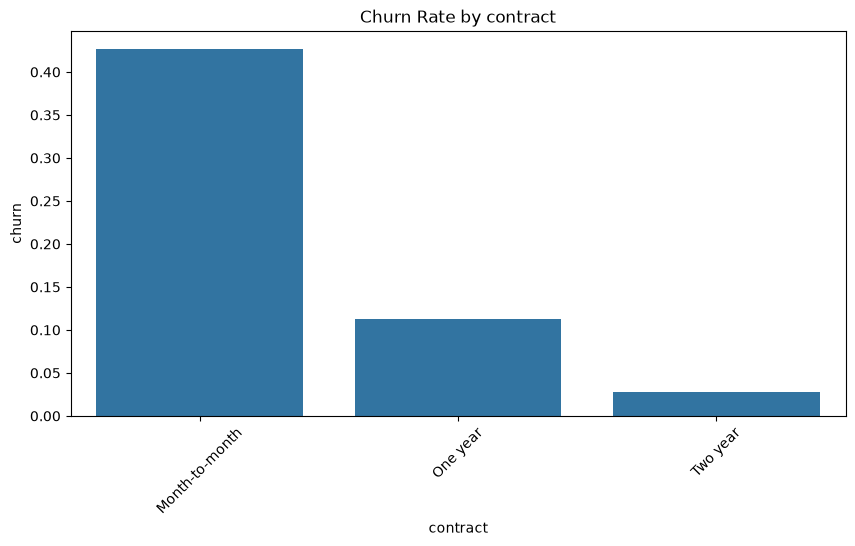

In [27]:
#Contract Risk 

BusinessVisualizer.plot_risk_segments(
    df,
    segment_column="contract",
    target_column="churn"
)


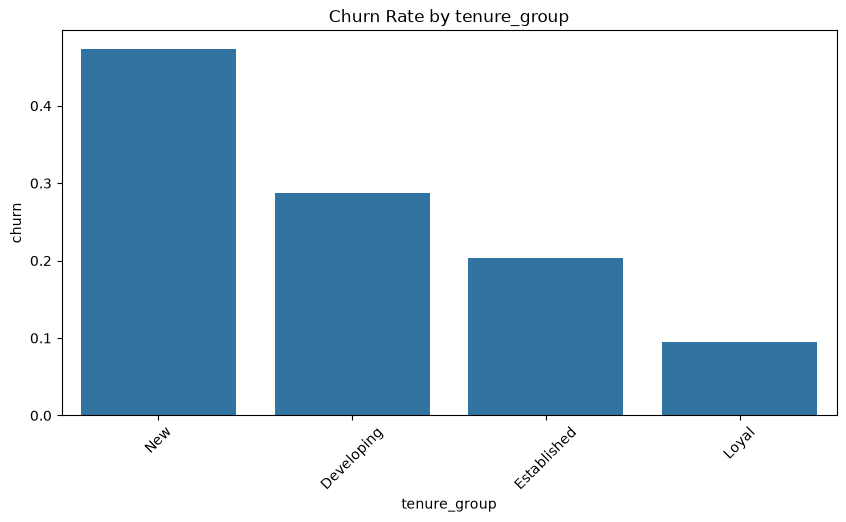

In [28]:
# Tenure Risk

BusinessVisualizer.plot_risk_segments(
    df,
    segment_column="tenure_group",
    target_column="churn"
)


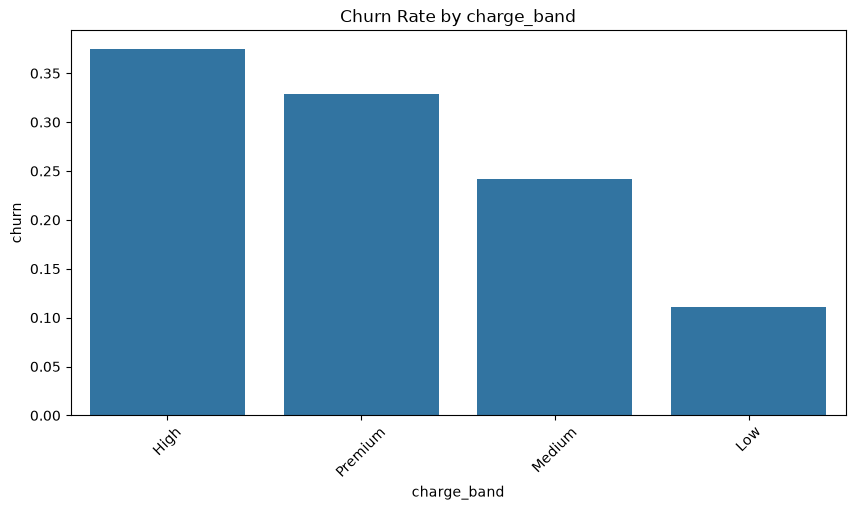

In [29]:
# Monthly Charges Risk

BusinessVisualizer.plot_risk_segments(
    df,
    segment_column="charge_band",
    target_column="churn"
)


# High-Risk Customer Personas

The churn analysis indicates that customer tenure, contract type, and charge band are strong predictors of customer attrition. The following personas summarize the key customer segments identified from the analysis.

---

## Persona 1: The New At-Risk Customer

### Profile
- New customer
- Less than 12 months tenure
- Churn rate ≈ 47%
- Often on a month-to-month contract

### Characteristics
- Limited loyalty to the company
- Still evaluating service quality and value
- More likely to switch providers after initial experiences

### Business Risk
This segment has the highest churn rate among all tenure groups and represents the most vulnerable customer segment.

### Recommended Actions
- Strengthen onboarding programs
- Conduct early customer satisfaction surveys
- Offer introductory loyalty incentives
- Proactively resolve service issues

---

## Persona 2: The Month-to-Month Customer

### Profile
- Month-to-month contract
- Churn rate ≈ 43%
- Minimal contractual commitment

### Characteristics
- High flexibility to leave at any time
- More price-sensitive than customers on long-term contracts
- Frequently compares competing providers

### Business Risk
Month-to-month customers are nearly four times more likely to churn than customers on one-year contracts and over fifteen times more likely to churn than customers on two-year contracts.

### Recommended Actions
- Promote annual and two-year contracts
- Provide contract upgrade discounts
- Offer bundled services with long-term commitments
- Develop personalized retention campaigns

---

## Persona 3: The Premium High-Spend Customer

### Profile
- Premium or high charge band customer
- Churn rate between 33% and 38%
- Generates substantial revenue

### Characteristics
- Pays above-average monthly fees
- Has higher service expectations
- May perceive pricing as poor value if service quality declines

### Business Risk
Although fewer in number, losing these customers has a significant financial impact because they contribute more revenue than lower-charge customers.

### Recommended Actions
- Provide premium customer support
- Introduce loyalty rewards
- Offer personalized discounts and retention packages
- Regularly assess customer satisfaction

---

## Persona 4: The Developing Customer

### Profile
- Tenure in the developing stage
- Churn rate ≈ 29%

### Characteristics
- Has remained beyond the initial onboarding period
- Still building long-term loyalty
- May leave if engagement declines

### Business Risk
This group represents a transition stage between high-risk new customers and loyal long-term customers.

### Recommended Actions
- Encourage long-term contracts
- Offer loyalty benefits after key tenure milestones
- Promote value-added services
- Maintain regular engagement

---

# Low-Risk Customer Persona

## Persona 5: The Loyal Long-Term Customer

### Profile
- Loyal tenure group
- Churn rate ≈ 9%
- Frequently on one-year or two-year contracts

### Characteristics
- Strong relationship with the company
- Stable service usage patterns
- High retention probability

### Business Value
This segment represents the company's most valuable customer base and should be protected from competitive targeting.

### Recommended Actions
- Maintain service quality
- Reward loyalty through exclusive benefits
- Use referral programs
- Identify characteristics that can be replicated across other customer segments

---

# Summary of Key Risk Segments

| Persona | Primary Risk Driver | Approximate Churn Rate |
|----------|-------------------|------------------------|
| New At-Risk Customer | Short tenure | 47% |
| Month-to-Month Customer | Contract type | 43% |
| Premium High-Spend Customer | High charges | 38% |
| Developing Customer | Moderate tenure | 29% |
| Loyal Long-Term Customer | Low risk segment | 9% |

## Overall Business Insight

The analysis shows that the most vulnerable customers are those with **short tenure, month-to-month contracts, and higher monthly charges**. Conversely, **long-term contracts and customer loyalty significantly reduce the likelihood of churn**. Retention efforts should therefore focus on moving customers from the **New** and **Month-to-Month** segments into the **Loyal Long-Term Customer** segment.

In [30]:
recommendations = (
    BusinessReportGenerator
    .generate_business_recommendations()
)

recommendations


,Recommendation,Expected Impact
0,Promote annual contracts,Lower churn
1,Launch onboarding program,Improve retention
2,Target high-risk accounts,Increase customer value
3,Review pricing strategy,Reduce churn drivers


### Business Impact

In [31]:
impact = (
    BusinessReportGenerator
    .calculate_business_impact(
        customers_at_risk=1000,
        retention_rate=0.15,
        average_customer_value=1000
    )
)

impact


{'Customers At Risk': 1000,
 'Retention Rate': 0.15,
 'Retained Customers': 150.0,
 'Estimated Savings': 150000.0}

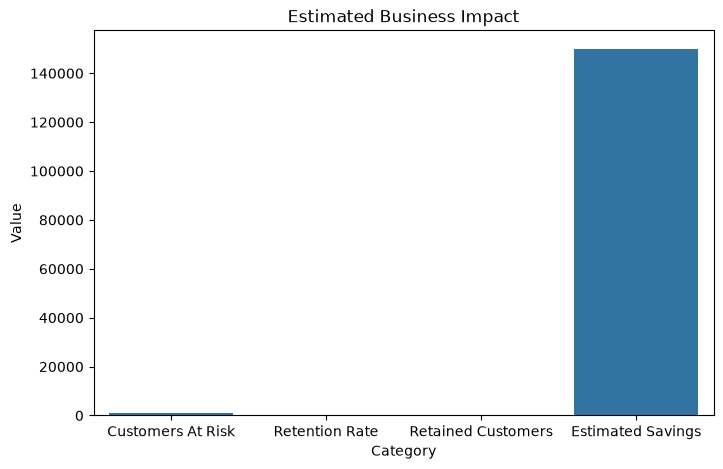

In [32]:
impact_df = pd.DataFrame({
    "Category": impact.keys(),
    "Value": impact.values()
})

BusinessVisualizer.plot_business_impact(
    impact_df
)


# Business Impact Interpretation

The estimated business impact analysis demonstrates the potential financial benefits of implementing customer retention strategies based on the machine learning churn predictions.

## Key Findings

- The model identified **1,000 customers** as being at risk of churning.
- Assuming a retention campaign success rate of **15%**, approximately **150 customers** can be retained.
- With an average customer value of **1,000 currency units**, the company could achieve estimated savings of approximately **150,000 currency units**.

## Business Implications

### Customer Retention Creates Significant Value
Although only a small proportion of at-risk customers are retained, the resulting financial impact is substantial. This highlights the importance of proactive churn prevention initiatives.

### Early Intervention is Cost-Effective
Targeting customers before they leave can generate considerable revenue preservation compared to acquiring new customers to replace lost ones.

### Data-Driven Retention Strategies
The churn prediction model enables the organization to focus retention resources on customers most likely to leave, improving the efficiency and effectiveness of marketing and customer success campaigns.

## Conclusion

The analysis shows that even modest improvements in customer retention can produce significant financial returns. By identifying high-risk customers and implementing targeted retention strategies, the company has the potential to reduce revenue loss and increase long-term customer lifetime value.

In [ ]:
# Executive Summary
executive_summary = (
    BusinessReportGenerator
    .generate_executive_summary()
)

executive_summary


,Area,Recommendation
0,Customer Retention,Target high-risk customers
1,Contract Strategy,Promote long-term contracts
2,Customer Success,Early intervention
3,Marketing,Personalized offers


In [ ]:
# Save the executive summary to a CSV file

FileManager.save_dataframe(
    executive_summary,
    "../reports/executive_summary.csv"
)


WindowsPath('../reports/executive_summary.csv')

In [35]:
# save the recommendations to a CSV file


FileManager.save_dataframe(
    recommendations,
    "../reports/business_recommendations.csv"
)


WindowsPath('../reports/business_recommendations.csv')

In [36]:
# export the final business report

BusinessReportGenerator.export_report(
    executive_summary=executive_summary,
    recommendations=recommendations,
    file_path="../reports/final_business_report.xlsx"
)


# Executive Summary

The Logistic Regression model was selected as the final model
based on its performance metrics and business interpretability.

Key findings include:

- Contract type strongly influences churn behaviour.
- Customer tenure is a major retention indicator.
- Monthly charges are associated with churn risk.
- Certain payment methods show elevated churn probability.
- Early customer engagement is critical for retention.

Because Logistic Regression provides interpretable coefficients,
business stakeholders can clearly understand the factors
contributing to customer churn.

# Key Findings

1. Logistic Regression was selected as the preferred model.

2. The model achieved strong predictive performance while
   remaining highly interpretable.

3. Contract type is one of the strongest churn indicators.

4. Customers with shorter tenure exhibit significantly
   higher churn risk.

5. Higher monthly charges are associated with increased
   customer attrition.

6. Certain payment methods contribute to elevated churn.

7. Targeted retention campaigns focused on the identified
   risk factors could substantially reduce revenue loss.

8. Logistic Regression coefficients provide transparent
   business explanations supporting data-driven decisions.


In [37]:
FileManager.save_dataframe(
    feature_importance_df,
    "../reports/logistic_regression_coefficients.csv"
)


WindowsPath('../reports/logistic_regression_coefficients.csv')